# Gamma width analysis in $^{47}\text{K}$ data

We look into the possible evolution of gamma resolution over the length of $^{47}\text{K}$ data taken in April 2024.

In [68]:
include("src/PhotoPeakFit.jl")

using Plots, DelimitedFiles, Plotly

plotly()

default(grid=false,
        seriestype=:step,
        framestyle=:box,
        lc=:black,
        dpi=600)



In [69]:
function retrievedata(file,clover,crystal)
    histogramnumber = 97+clover+crystal
    return readdlm("K47_data/K47_T1_$file.his-$histogramnumber.dat",comments=true)
end

function retrievecalibration(clover,crystal)
    line=1+clover*4+crystal
    return readdlm("calibrations/K47-calibration.dat")[line,:]
end

retrievecalibration (generic function with 1 method)

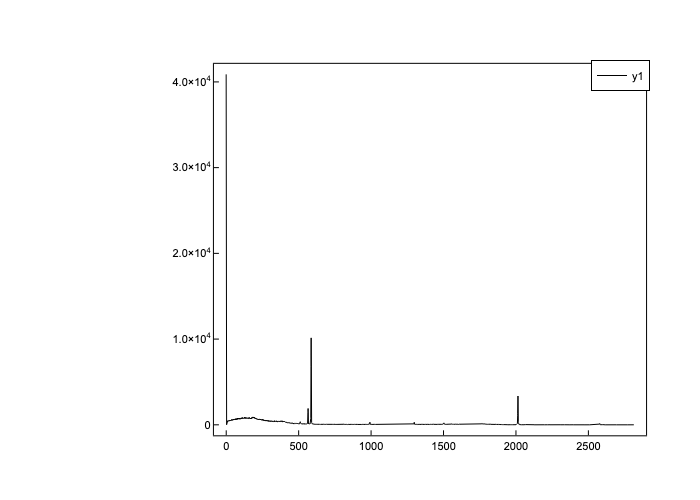

In [83]:

clover,crystal=0,3

data=deepcopy(retrievedata("006-1",clover,crystal));

calibration=retrievecalibration(clover,crystal)
datacalibrated=[data[:,1].*calibration[2].+calibration[1]  data[:,2]]

Plots.plot(datacalibrated[:,1],datacalibrated[:,2])


[352.50670478852936, -0.32095701071798344, 22677.224507928197, 586.0823365759335, 0.9228222945594766]


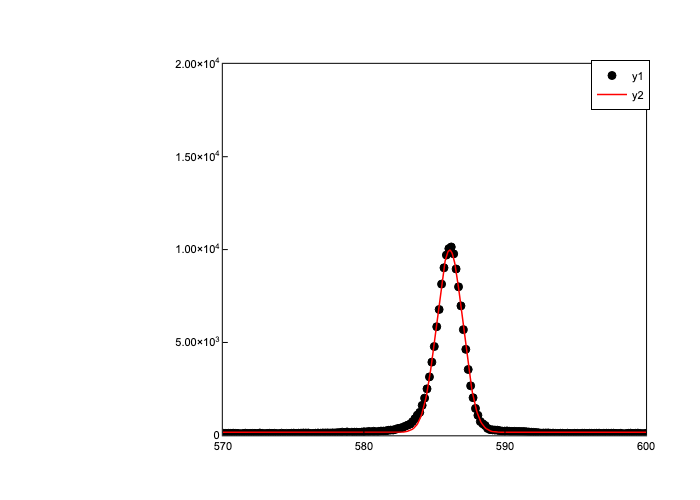

In [84]:
Plots.plot(datacalibrated[:,1],datacalibrated[:,2],xlims=(500,600),ylims=(0,2e4))

xlow,xhigh=570,600

p,s,f=PhotopeakFit.gaussianfit(datacalibrated,xlow,xhigh,[200,0.0,10000,585,1])
println(p)

Plots.scatter(datacalibrated[:,1],datacalibrated[:,2],xlims=(xlow,xhigh),ylims=(0,2e4),mc=:black)
Plots.plot!(e->f(e,p),xlow,xhigh,lc=:red,lw=1.5,seriestype=:line)

